# 34 — Build joint historical scenarios and portfolio P&L

Convert same-date factor movements into daily desk and portfolio profit or loss.

The synthetic history is not independent random noise. It uses correlated economic drivers, volatility clustering and named stress regimes. Same-date dependence is retained so rates, credit, equity, FX and commodities move together.

This step uses: Ten years of synthetic regime-aware factor changes and trade-level sensitivities.

It produces: Factor, desk and portfolio P&L for each historical date.

> Basel norm applied: MAR33 requires a sufficiently long history and joint stressed correlation across relevant factors.

$$P\&L_t=\sum_k s_k\Delta x_{k,t}+\text{nonlinear repricing effect}_t$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260908T033903126517Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
history=stage('04_synthetic_factor_history'); pnl=stage('06_daily_factor_pnl'); history['date']=pd.to_datetime(history.date)
print(f"History covers {history.date.min().date()} to {history.date.max().date()} and is labelled {history.data_status.iloc[0]}.")
history_sample=history[['date','risk_factor_id','daily_change','level','market_regime','data_status']].head(5)
print(f'Displayed sample: first 5 of {len(history):,} factor-date observations.')
display(history_sample)
example=pnl.iloc[0]; print(f"Worked row: sensitivity × factor change plus nonlinear effect = {money(example.factor_pnl_inr)}")

History covers 2016-07-01 to 2026-06-30 and is labelled SYNTHETIC_REGIME_AWARE.
Displayed sample: first 5 of 153,872 factor-date observations.


,date,risk_factor_id,daily_change,level,market_regime,data_status
0,2016-07-01,APPLE,0.0000,42.0859,ordinary_market,SYNTHETIC_REGIME_AWARE
1,2016-07-04,APPLE,0.0055,42.3193,ordinary_market,SYNTHETIC_REGIME_AWARE
2,2016-07-05,APPLE,0.0137,42.9012,ordinary_market,SYNTHETIC_REGIME_AWARE
3,2016-07-06,APPLE,0.0019,42.9814,ordinary_market,SYNTHETIC_REGIME_AWARE
4,2016-07-07,APPLE,0.0077,43.3140,ordinary_market,SYNTHETIC_REGIME_AWARE


Worked row: sensitivity × factor change plus nonlinear effect = INR 0.00 crore


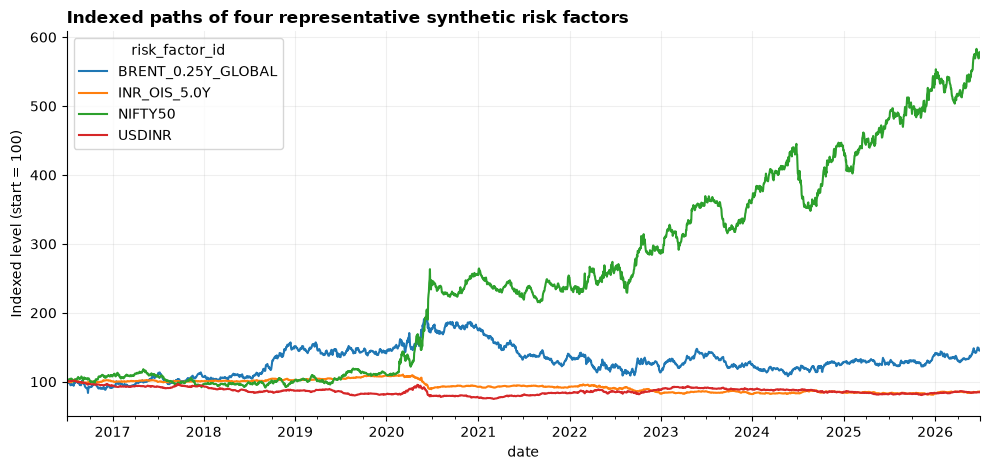

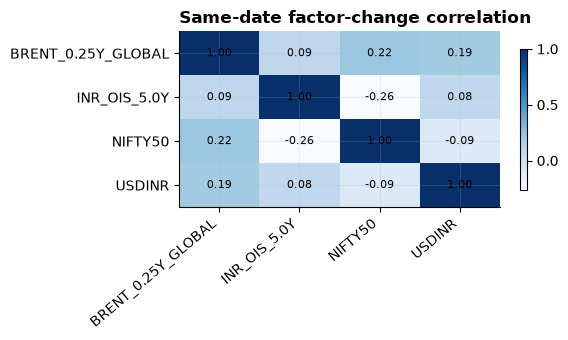

In [3]:
selected=history[history.risk_factor_id.isin(['USDINR','NIFTY50','INR_OIS_5.0Y','BRENT_0.25Y_GLOBAL'])].pivot(index='date',columns='risk_factor_id',values='level'); normalized=selected/selected.iloc[0]*100
ax=normalized.plot(); ax.set_ylabel('Indexed level (start = 100)'); ax.set_title('Indexed paths of four representative synthetic risk factors',loc='left',weight='bold'); plt.tight_layout(); plt.show()
changes=history[history.risk_factor_id.isin(selected.columns)].pivot(index='date',columns='risk_factor_id',values='daily_change').corr(); heatmap(changes,'Same-date factor-change correlation',value_format='.2f')

The line chart indexes four representative factor levels to 100 on the first date, making changes in differently scaled markets comparable. Diverging paths show how rates, equity, FX and commodity conditions evolve through the synthetic regimes. The correlation heatmap uses daily changes, not levels: positive cells mean two factors usually move in the same direction on the same date, while negative cells mean they tend to move in opposite directions.